# 01. EDA: рекомендации банковских продуктов

Цель ноутбука — провести первичный анализ данных, понять структуру клиентских признаков и продуктовой истории, а также подготовить выводы для постановки рекомендательной задачи.

Основная идея проекта: рекомендовать клиенту **новые продукты**, которых у него ещё не было в предыдущем месяце.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT / "src"))

from bank_recs.config import PRODUCT_COLS, PRODUCT_NAMES_RU
from bank_recs.data import clean_dataframe, load_raw_data, available_months

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

## Загрузка данных

Основной файл должен лежать в `data/raw/train_ver2.csv`. Если его пока нет, ноутбук может использовать маленький синтетический файл `train_ver2_sample.csv`, который создаётся скриптом `scripts/make_sample_data.py`.

In [2]:
data_path = PROJECT_ROOT / "data" / "raw" / "train_ver2.csv"
sample_path = PROJECT_ROOT / "data" / "raw" / "train_ver2_sample.csv"

if not data_path.exists():
    if not sample_path.exists():
        !python {PROJECT_ROOT / "scripts" / "make_sample_data.py"}
    data_path = sample_path

# Для первого знакомства
# df_raw = load_raw_data(data_path, nrows=500_000)
df_raw = load_raw_data(data_path)
df = clean_dataframe(df_raw)

print(f"Файл: {data_path}")
print(f"Размер данных: {df.shape}")
df.head()

Файл: /Users/aleksandrfedyuk/Desktop/МАГА/bank-product-recommendation/data/raw/train_ver2.csv
Размер данных: (13647309, 51)


,fecha_dato,ncodpers,ind_empleado,pais_residencia,sexo,age,fecha_alta,ind_nuevo,antiguedad,indrel,ult_fec_cli_1t,indrel_1mes,tiprel_1mes,indresi,indext,conyuemp,canal_entrada,indfall,tipodom,cod_prov,nomprov,ind_actividad_cliente,renta,segmento,ind_ahor_fin_ult1,ind_aval_fin_ult1,ind_cco_fin_ult1,ind_cder_fin_ult1,ind_cno_fin_ult1,ind_ctju_fin_ult1,ind_ctma_fin_ult1,ind_ctop_fin_ult1,ind_ctpp_fin_ult1,ind_deco_fin_ult1,ind_deme_fin_ult1,ind_dela_fin_ult1,ind_ecue_fin_ult1,ind_fond_fin_ult1,ind_hip_fin_ult1,ind_plan_fin_ult1,ind_pres_fin_ult1,ind_reca_fin_ult1,ind_tjcr_fin_ult1,ind_valo_fin_ult1,ind_viv_fin_ult1,ind_nomina_ult1,ind_nom_pens_ult1,ind_recibo_ult1,month,months_from_join,prev_product_count
0,2015-01-28,1375586,N,ES,H,35.0,2015-01-12,0.0,6.0,1.0,unknown,1.0,A,S,N,unknown,KHL,N,1.0,29.0,MALAGA,1.0,87218.10,02 - PARTICULARES,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2015-01,0.0,1
1,2015-01-28,1050611,N,ES,V,23.0,2012-08-10,0.0,35.0,1.0,unknown,1,I,S,S,unknown,KHE,N,1.0,13.0,CIUDAD REAL,0.0,35548.74,03 - UNIVERSITARIO,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2015-01,29.0,1
2,2015-01-28,1050612,N,ES,V,23.0,2012-08-10,0.0,35.0,1.0,unknown,1,I,S,N,unknown,KHE,N,1.0,13.0,CIUDAD REAL,0.0,122179.11,03 - UNIVERSITARIO,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2015-01,29.0,1
3,2015-01-28,1050613,N,ES,H,22.0,2012-08-10,0.0,35.0,1.0,unknown,1,I,S,N,unknown,KHD,N,1.0,50.0,ZARAGOZA,0.0,119775.54,03 - UNIVERSITARIO,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2015-01,29.0,1
4,2015-01-28,1050614,N,ES,V,23.0,2012-08-10,0.0,35.0,1.0,unknown,1,A,S,N,unknown,KHE,N,1.0,50.0,ZARAGOZA,1.0,NaN,03 - UNIVERSITARIO,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2015-01,29.0,1


## Общая структура данных

In [3]:
print("Период наблюдений:", df["month"].min(), "—", df["month"].max())
print("Количество месяцев:", df["month"].nunique())
print("Количество клиентов:", df["ncodpers"].nunique())
print("Количество продуктовых колонок:", len(PRODUCT_COLS))
print("Доступные месяцы:", available_months(df))

Период наблюдений: 2015-01 — 2016-05
Количество месяцев: 17
Количество клиентов: 956645
Количество продуктовых колонок: 24
Доступные месяцы: ['2015-01', '2015-02', '2015-03', '2015-04', '2015-05', '2015-06', '2015-07', '2015-08', '2015-09', '2015-10', '2015-11', '2015-12', '2016-01', '2016-02', '2016-03', '2016-04', '2016-05']


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13647309 entries, 0 to 13647308
Data columns (total 51 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   fecha_dato             datetime64[ns]
 1   ncodpers               int64         
 2   ind_empleado           object        
 3   pais_residencia        object        
 4   sexo                   object        
 5   age                    float64       
 6   fecha_alta             datetime64[ns]
 7   ind_nuevo              float64       
 8   antiguedad             float64       
 9   indrel                 float64       
 10  ult_fec_cli_1t         object        
 11  indrel_1mes            object        
 12  tiprel_1mes            object        
 13  indresi                object        
 14  indext                 object        
 15  conyuemp               object        
 16  canal_entrada          object        
 17  indfall                object        
 18  tipodom             

## Пропуски

В банковских данных пропуски часто несут смысл: например, неизвестный доход или неизвестный канал привлечения. В модели мы будем не удалять такие строки, а обрабатывать пропуски через пайплайн.

In [5]:
missing = (
    df.isna().mean()
    .sort_values(ascending=False)
    .rename("missing_share")
    .to_frame()
)
missing.head(20)

,missing_share
renta,0.204756
cod_prov,0.006858
tipodom,0.002032
ind_nuevo,0.002032
ind_actividad_cliente,0.002032
antiguedad,0.002032
indrel,0.002032
fecha_alta,0.002032
age,0.002032
months_from_join,0.002032


## Динамика по месяцам

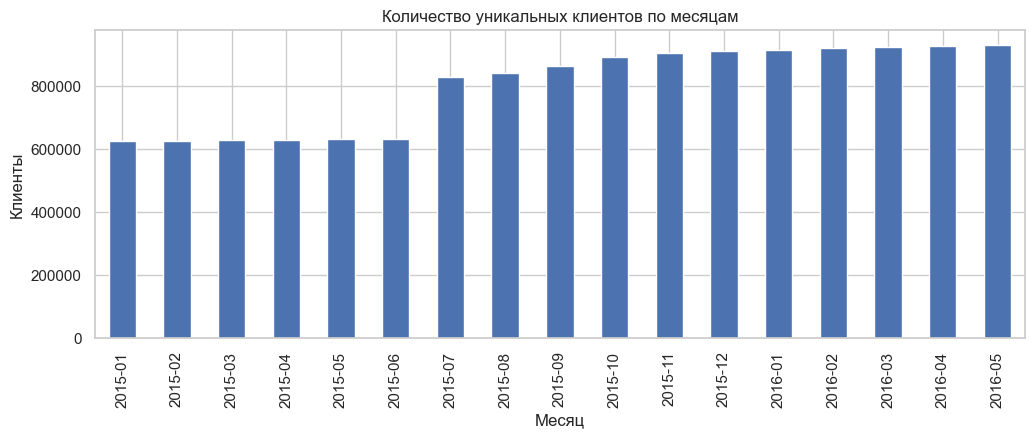

In [6]:
month_counts = df.groupby("month")["ncodpers"].nunique()
month_counts.plot(kind="bar", figsize=(12, 4), title="Количество уникальных клиентов по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Клиенты")
plt.show()

## Распределение клиентских признаков

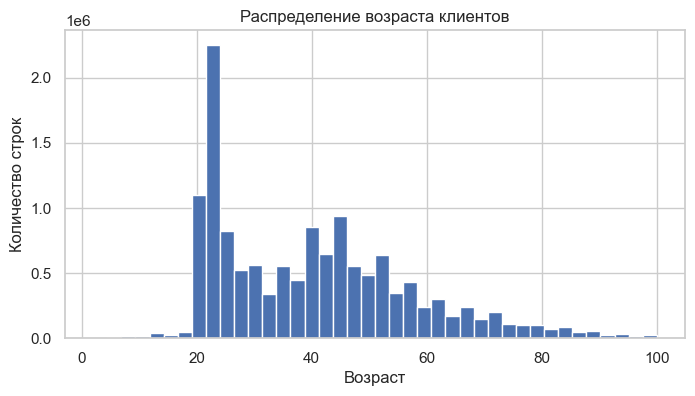

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
df["age"].dropna().clip(0, 100).hist(bins=40, ax=ax)
ax.set_title("Распределение возраста клиентов")
ax.set_xlabel("Возраст")
ax.set_ylabel("Количество строк")
plt.show()

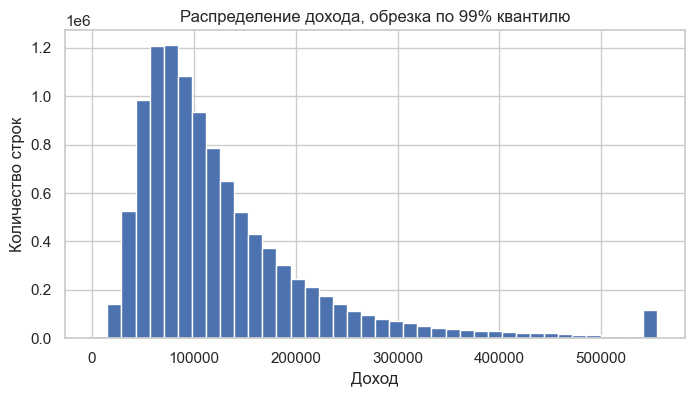

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
df["renta"].dropna().clip(upper=df["renta"].quantile(0.99)).hist(bins=40, ax=ax)
ax.set_title("Распределение дохода, обрезка по 99% квантилю")
ax.set_xlabel("Доход")
ax.set_ylabel("Количество строк")
plt.show()

In [9]:
for col in ["sexo", "segmento", "tiprel_1mes", "ind_actividad_cliente"]:
    if col in df.columns:
        display(df[col].value_counts(dropna=False).head(10).to_frame("count"))

,count
sexo,
V,7424252
H,6195253
unknown,27804


,count
segmento,
02 - PARTICULARES,7960220
03 - UNIVERSITARIO,4935579
01 - TOP,562142
unknown,189368


,count
tiprel_1mes,
I,7304875
A,6187123
unknown,149781
P,4656
R,870
N,4


,count
ind_actividad_cliente,
0.0,7384390
1.0,6235185
NaN,27734


## Популярность продуктов

Смотрим, какие продукты чаще всего уже есть у клиентов. Это понадобится для baseline по популярности.

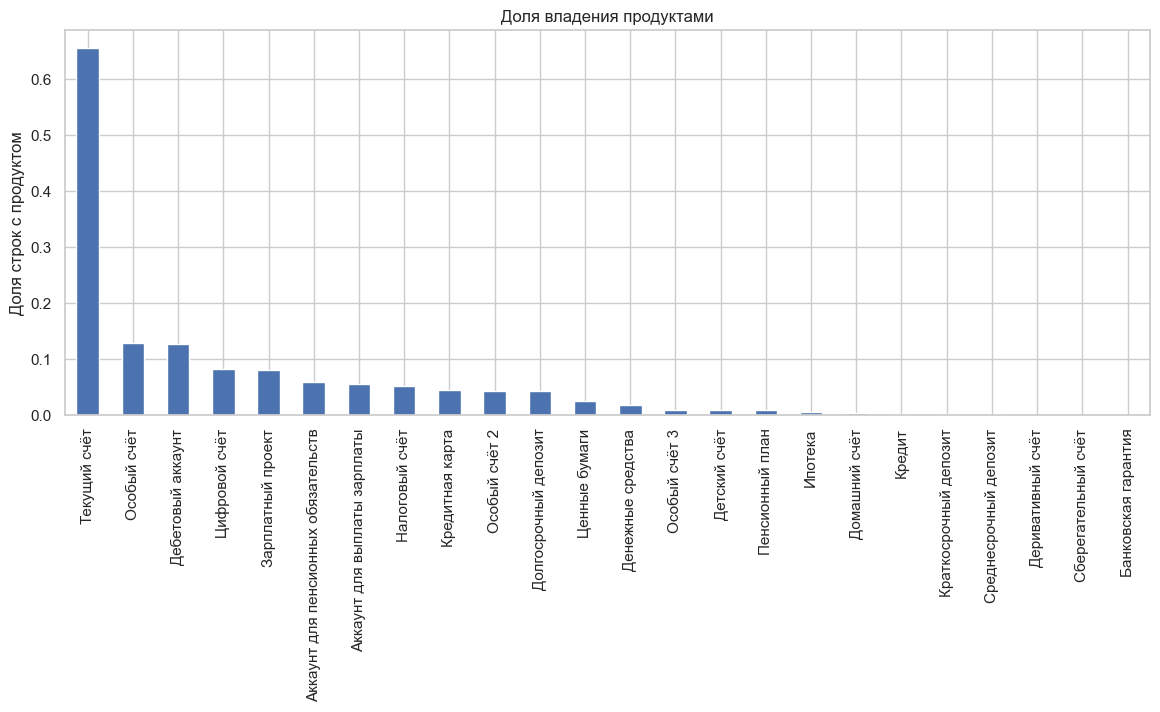

,share
ind_cco_fin_ult1,0.655484
ind_ctop_fin_ult1,0.129008
ind_recibo_ult1,0.127916
ind_ecue_fin_ult1,0.082744
ind_cno_fin_ult1,0.080867
ind_nom_pens_ult1,0.059359
ind_nomina_ult1,0.054660
ind_reca_fin_ult1,0.052536
ind_tjcr_fin_ult1,0.044389
ind_ctpp_fin_ult1,0.043306


In [10]:
product_popularity = df[PRODUCT_COLS].mean().sort_values(ascending=False)
product_popularity.rename(index=PRODUCT_NAMES_RU).plot(kind="bar", figsize=(14, 5), title="Доля владения продуктами")
plt.ylabel("Доля строк с продуктом")
plt.show()

product_popularity.to_frame("share").head(10)

## Новые покупки между месяцами

Для рекомендательной постановки важны не текущие продукты, а продукты, которые появились у клиента между соседними месяцами.

Новые продукты: 2016-04 -> 2016-05


,new_purchases
ind_recibo_ult1,10163
ind_nom_pens_ult1,5513
ind_nomina_ult1,5488
ind_tjcr_fin_ult1,4248
ind_cco_fin_ult1,3854
ind_ecue_fin_ult1,2709
ind_cno_fin_ult1,2346
ind_ctma_fin_ult1,512
ind_reca_fin_ult1,279
ind_ctop_fin_ult1,226


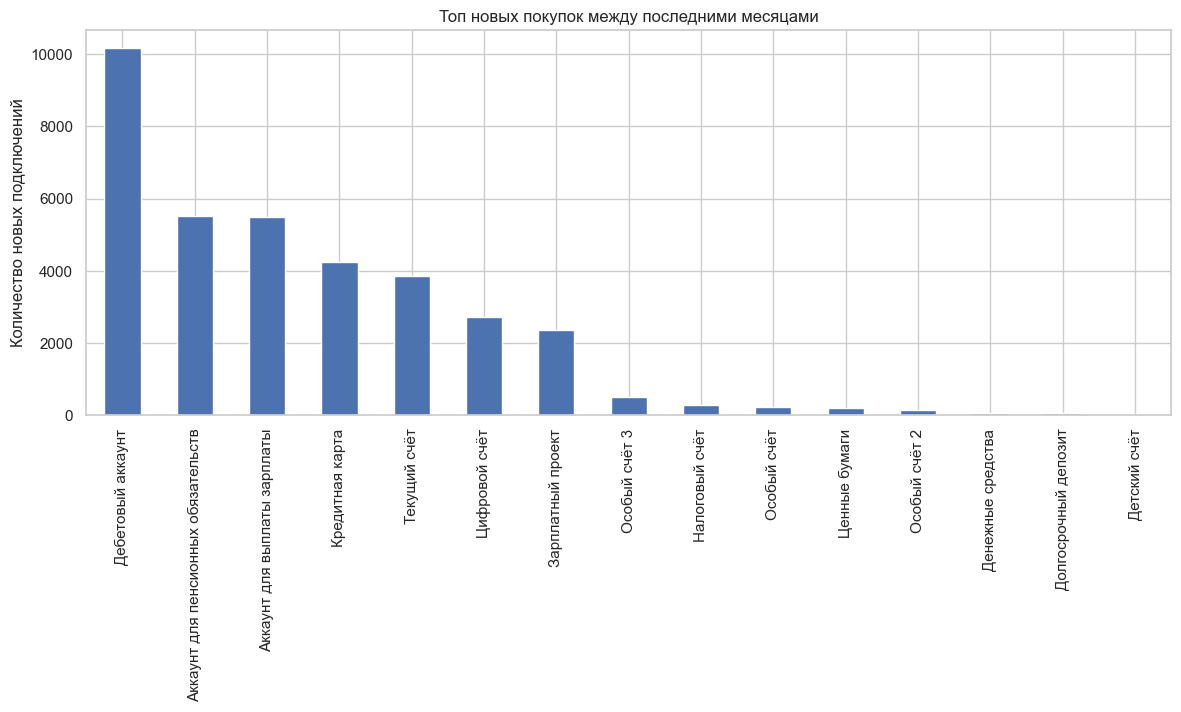

In [11]:
def new_products_between_months(df, month_t, month_next):
    left = df[df["month"] == month_t][["ncodpers"] + PRODUCT_COLS].drop_duplicates("ncodpers")
    right = df[df["month"] == month_next][["ncodpers"] + PRODUCT_COLS].drop_duplicates("ncodpers")
    merged = left.merge(right, on="ncodpers", suffixes=("_t", "_next"))
    result = {}
    for product in PRODUCT_COLS:
        result[product] = ((merged[f"{product}_t"] == 0) & (merged[f"{product}_next"] == 1)).sum()
    return pd.Series(result).sort_values(ascending=False)

months = available_months(df)
if len(months) >= 2:
    new_counts = new_products_between_months(df, months[-2], months[-1])
    print(f"Новые продукты: {months[-2]} -> {months[-1]}")
    display(new_counts.to_frame("new_purchases").head(15))
    new_counts.rename(index=PRODUCT_NAMES_RU).head(15).plot(kind="bar", figsize=(14, 5), title="Топ новых покупок между последними месяцами")
    plt.ylabel("Количество новых подключений")
    plt.show()

## Продуктовый портфель клиента

In [12]:
df["product_count"] = df[PRODUCT_COLS].sum(axis=1)
df["product_count"].describe()

count    1.364731e+07
mean     1.462021e+00
std      1.512991e+00
min      0.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      1.500000e+01
Name: product_count, dtype: float64

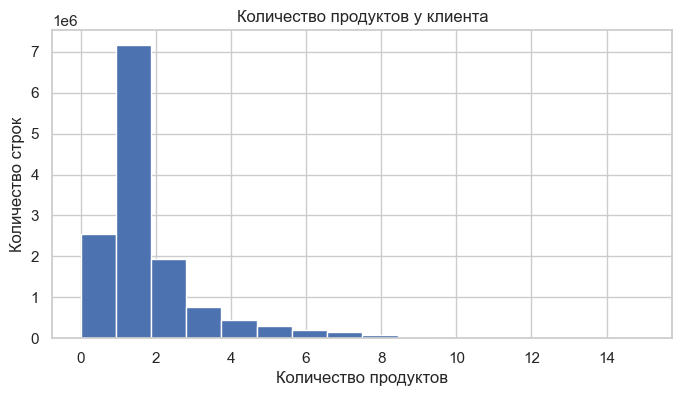

In [13]:
df["product_count"].clip(upper=15).hist(bins=16, figsize=(8, 4))
plt.title("Количество продуктов у клиента")
plt.xlabel("Количество продуктов")
plt.ylabel("Количество строк")
plt.show()

## Выводы EDA

В ходе первичного анализа был изучен полный датасет банковских клиентов: **13 647 309 строк**, **956 645 уникальных клиентов**, **17 месяцев наблюдений** с января 2015 по май 2016 года. В данных присутствуют **24 продуктовые колонки** `ind_*_ult1`, которые отражают наличие банковских продуктов у клиента.

### 1. Временная структура данных

Данные представлены в виде ежемесячных срезов клиентской базы. Это означает, что задача имеет временную природу: модель должна использовать информацию о клиенте и его продуктах в месяце `t`, чтобы предсказать появление новых продуктов в месяце `t+1`.

Из-за этого для валидации нельзя использовать случайное разбиение `train_test_split`, так как оно может привести к утечке информации из будущего. Корректнее использовать разбиение по времени, например:

- обучение: исторические месяцы до выбранного периода валидации;
- валидация: предсказание новых продуктов для следующего месяца.

В дальнейшем в проекте задача будет формулироваться как прогноз новых покупок между соседними месяцами.

### 2. Пропуски и качество данных

Наибольшая доля пропусков наблюдается в признаке `renta` — около **20.5%**. Также небольшая доля пропусков есть в признаках `cod_prov`, `tipodom`, `ind_nuevo`, `ind_actividad_cliente`, `antiguedad`, `indrel`, `fecha_alta`, `age` и `months_from_join`.

Так как пропуски в банковских данных могут нести бизнес-смысл, строки с пропусками не следует удалять. В пайплайне моделирования нужно использовать обработку пропусков:

- для числовых признаков — заполнение медианой или специальным значением;
- для категориальных признаков — заполнение значением `unknown`;
- для продуктовых признаков — приведение к бинарному формату `0/1`.

### 3. Клиентские сегменты

По сегментации видно, что основная часть наблюдений относится к сегменту `02 - PARTICULARES`, затем идёт `03 - UNIVERSITARIO`, а сегмент `01 - TOP` заметно меньше. Это важно для моделирования: поведение клиентов разных сегментов может отличаться, поэтому `segmento` стоит использовать как категориальный признак.

По признаку `tiprel_1mes` заметны две основные группы: неактивные клиенты `I` и активные клиенты `A`. Это важный признак для рекомендаций, так как активные клиенты с большей вероятностью могут подключать новые продукты.

### 4. Популярность текущих продуктов

Самый распространённый продукт — `ind_cco_fin_ult1` / текущий счёт: он есть примерно у **65.5%** строк. Далее идут `ind_ctop_fin_ult1`, `ind_recibo_ult1`, `ind_ecue_fin_ult1`, `ind_cno_fin_ult1`, `ind_nom_pens_ult1` и `ind_nomina_ult1`.

Это показывает, что продуктовый портфель клиентов сильно несбалансирован: часть продуктов массовые, а часть встречается редко. Поэтому модель, которая будет просто рекомендовать самые популярные продукты, может стать хорошим baseline, но для персонализации нужен учёт клиентских признаков и истории владения продуктами.

### 5. Новые покупки между месяцами

Для рекомендательной задачи важны не продукты, которые уже есть у клиента, а именно **новые подключения** между месяцами. На переходе `2016-04 -> 2016-05` чаще всего появлялись:

- `ind_recibo_ult1` — 10 163 новых подключения;
- `ind_nom_pens_ult1` — 5 513;
- `ind_nomina_ult1` — 5 488;
- `ind_tjcr_fin_ult1` — 4 248;
- `ind_cco_fin_ult1` — 3 854;
- `ind_ecue_fin_ult1` — 2 709;
- `ind_cno_fin_ult1` — 2 346.

Эти результаты подтверждают, что целевой признак нужно строить как переход продукта из состояния `0` в месяце `t` в состояние `1` в месяце `t+1`.

### 6. Продуктовый портфель клиента

Среднее количество продуктов на строку — около **1.46**, медиана — **1 продукт**, максимум — **15 продуктов**. Это означает, что у большинства клиентов небольшой продуктовый портфель, а задача банка состоит в том, чтобы подобрать наиболее релевантные дополнительные продукты.

На этапе инференса уже имеющиеся у клиента продукты необходимо исключать из рекомендаций, потому что бизнес-задача состоит в предложении новых продуктов.

### 7. Постановка ML-задачи после EDA

По итогам EDA задачу корректно формулировать как рекомендательную задачу ранжирования:

> для каждого клиента на основе его признаков и продуктовой истории в месяце `t` предсказать топ-7 продуктов, которые могут появиться у него в месяце `t+1`.

Целевой признак:

```text
target_product = 1, если продукт отсутствовал у клиента в месяце t и появился в месяце t+1
target_product = 0, если продукт не появился
```

Формат обучающей выборки для модели:

```text
строка = клиент × месяц × продукт
target = факт нового подключения продукта в следующем месяце
```

### 8. Метрики качества

Так как банк показывает клиенту ограниченный список предложений, качество модели нужно оценивать ranking-метриками:

- `MAP@7` — основная метрика, учитывает порядок рекомендаций;
- `Recall@7` — показывает, сколько реальных новых покупок попало в топ-7;
- `Precision@7` — показывает точность рекомендательного списка;
- `HitRate@7` — показывает долю клиентов, у которых модель угадала хотя бы один новый продукт;
- `Coverage` — показывает, насколько разнообразны рекомендации.

### 9. Вывод для дальнейшего моделирования

EDA показывает, что в проекте нужно:

1. использовать временное разбиение данных;
2. строить таргет как появление новых продуктов между соседними месяцами;
3. не рекомендовать клиенту продукты, которые у него уже есть;
4. использовать baseline по популярным новым продуктам;
5. обучать основную модель на парах `клиент-продукт`;
6. добавить лаговые признаки продуктового портфеля;
7. логировать эксперименты и ranking-метрики в MLflow.

